# Point Source Injector

<div class="alert alert-block alert-info">

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly.

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.


In [6]:
%%capture
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import SkyCoord

from astromodels.core.polarization import LinearPolarization

from threeML import Band, Model, PointSource

from histpy import Histogram
from mhealpy import HealpixMap

from cosipy import SpacecraftFile, SourceInjector
from cosipy.polarization.conventions import IAUPolarizationConvention
from cosipy.polarization.polarization_angle import PolarizationAngle
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file

%matplotlib inline


In [ ]:
data_dir = Path("")  # Current directory by default. Modify if you want a different path

## Get the data

The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size.


In [8]:
%%capture
response_path = data_dir/"SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5"

# download response file ~839.62 MB
fetch_wasabi_file("COSI-SMEX/develop/Data/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5", response_path, checksum = 'eb72400a1279325e9404110f909c7785')

In [9]:
%%capture
orientation_path = data_dir/"20280301_3_month_with_orbital_info.fits"

# download orientation file ~596.06 MB
fetch_wasabi_file("COSI-SMEX/develop/Data/Orientation/20280301_3_month_with_orbital_info.fits", orientation_path, checksum = 'bf59c4b79bc95ab68bcd376357f7bd40')

## Inject a source response


### Method 1 : Define the point source


In this method, we are setting up an analytical function (eg: a power law model) to simulate the spectral characteristics of a point source:


In [10]:
# Defind the Crab spectrum

alpha_inj = -1.99
beta_inj = -2.32
E0_inj = 531.0 * (alpha_inj - beta_inj) * u.keV
xp_inj = E0_inj * (alpha_inj + 2) / (alpha_inj - beta_inj)
piv_inj = 100.0 * u.keV
K_inj = 7.56e-4 / u.cm / u.cm / u.s / u.keV

spectrum_inj = Band()

spectrum_inj.alpha.min_value = -2.14
spectrum_inj.alpha.max_value = 3.0
spectrum_inj.beta.min_value = -5.0
spectrum_inj.beta.max_value = -2.15
spectrum_inj.xp.min_value = 1.0

spectrum_inj.alpha.value = alpha_inj
spectrum_inj.beta.value = beta_inj
spectrum_inj.xp.value = xp_inj.value
spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value

spectrum_inj.xp.unit = xp_inj.unit
spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit

10:33:45 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=869928;file:///Users/krishnatejavedula/miniforge3/envs/COSI-Pol/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=214739;file:///Users/krishnatejavedula/miniforge3/envs/COSI-Pol/lib/python3.10/site-packages/astromodels/core/parameter.py#810\810]8;;\

In [11]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=184.5551, b=-05.7877, frame="galactic", unit="deg")

# define the Crab point source
point_source = PointSource(
    "Crab", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=spectrum_inj
)

# define the model. The model can contain multiple point sources.
model = Model(point_source)

### Read orientation file


In [12]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.open(orientation_path)

### Get the expected counts and save to a data file


In [13]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path)

CPU times: user 3.9 s, sys: 449 ms, total: 4.35 s
Wall time: 6.18 s


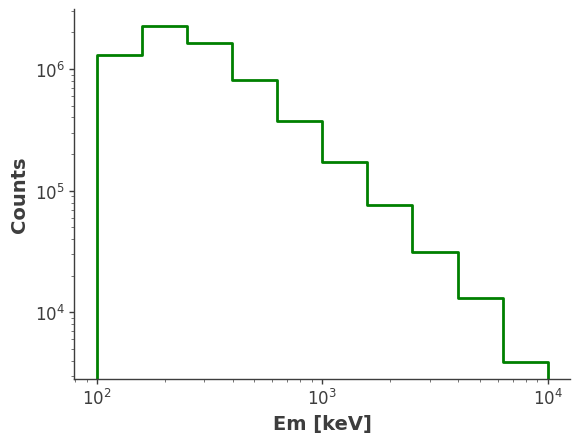

In [14]:
%%time

file_path = "Crab_model_injected.h5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

### Compare with Simulation


In [15]:
%%capture
# download simulated data
simulated_data_path = data_dir/"crab_3months_unbinned_data.hdf5"

# download orientation file ~89.50 MB
if not simulated_data_path.exists():
    fetch_wasabi_file("COSI-SMEX/cosipy_tutorials/source_injector/crab_3months_unbinned_data.hdf5", simulated_data_path, checksum = '787f17ee7c23e5b94fb77cc52a117422')

Text(0.5, 1.0, 'Simulated and injected Crab')

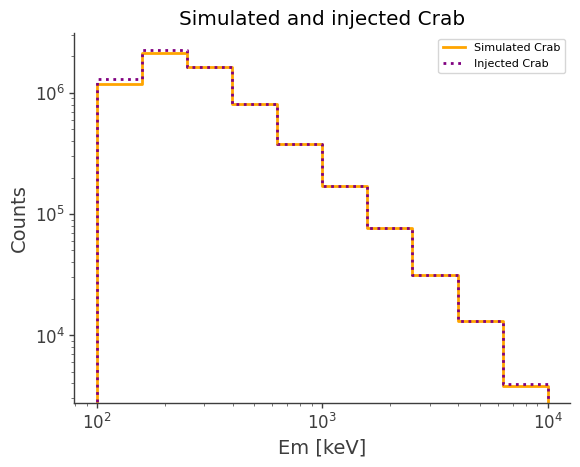

In [16]:
simulated = Histogram.open(simulated_data_path)
injected = Histogram.open("Crab_model_injected.h5")

ax, plot = simulated.project("Em").draw(label="Simulated Crab", color="orange")
injected.project("Em").draw(
    ax, label="Injected Crab", color="purple", linestyle="dotted"
)

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Crab")

### Method 2: Read the spectrum from a file


In this method, we're loading spectral data from a file (crab_spec.dat) and visualizing it:


In [17]:
# Load data from the text file, skipping the index column
dataFlux = np.genfromtxt(
    "crab_spec.dat", comments="#", usecols=(2), skip_footer=1, skip_header=5
)
dataEn = np.genfromtxt(
    "crab_spec.dat", comments="#", usecols=(1), skip_footer=1, skip_header=5
)

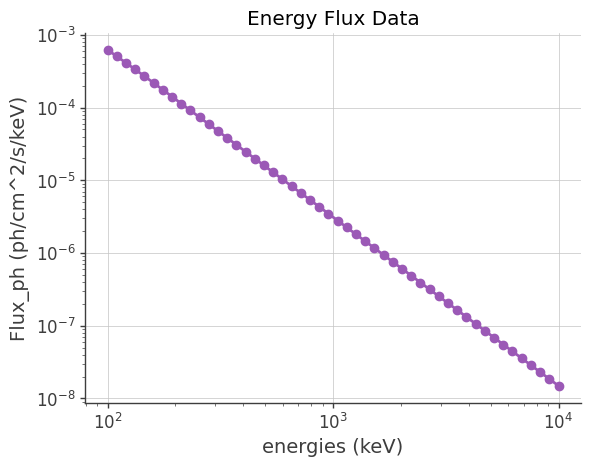

In [18]:
# Plot the data
plt.plot(dataEn, dataFlux, marker="o", linestyle="-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("energies (keV)")
# plt.ylabel("Flux (keV cm^-2 s^-1)")
plt.ylabel("Flux_ph (ph/cm^2/s/keV)")
plt.title("Energy Flux Data")
plt.grid(True)
plt.show()

We use a custom class `SpecFromDat` to define a spectrum from data loaded from a CSV file `crab_spec.dat`


In [19]:
spectrum = SpecFromDat(K=1 / 18, dat="crab_spec.dat")

# Define the coordinate of the point source
source_coord = SkyCoord(l=184.5551, b=-05.7877, frame="galactic", unit="deg")

# define the Crab point source
point_source = PointSource(
    "Crab", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=spectrum
)

# define the model. One model can contain multiple point sources.
model = Model(point_source)

### Read orientation file


In [20]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.open(orientation_path)

### Get the expected counts and save to a data file


In [21]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path)

CPU times: user 5.23 s, sys: 595 ms, total: 5.82 s
Wall time: 7.82 s


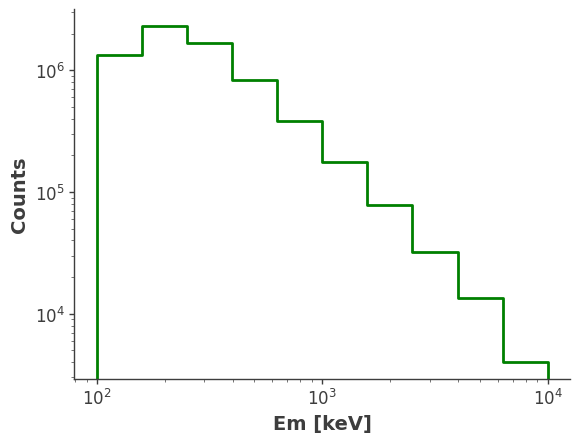

In [22]:
%%time

file_path = "Crab_piecewise_injected.h5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

### Compare with Simulation


In [23]:
%%capture
# download simulated data
simulated_data_path = data_dir/"crab_3months_unbinned_data.hdf5"

# download orientation file ~89.50 MB
fetch_wasabi_file("COSI-SMEX/cosipy_tutorials/source_injector/crab_3months_unbinned_data.hdf5", simulated_data_path, checksum = '787f17ee7c23e5b94fb77cc52a117422')

Text(0.5, 1.0, 'Simulated and injected Crab')

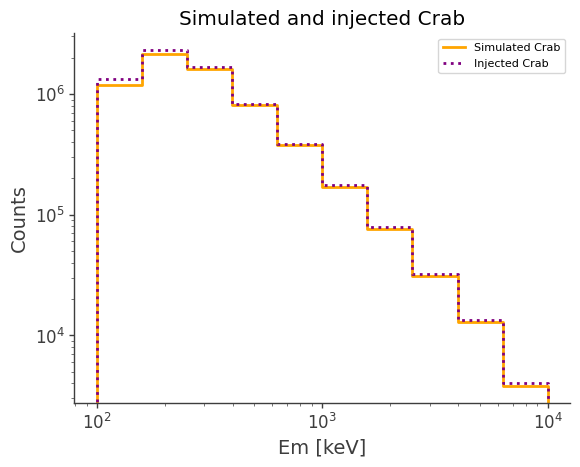

In [24]:
simulated = Histogram.open(simulated_data_path)
injected = Histogram.open("Crab_piecewise_injected.h5")

ax, plot = simulated.project("Em").draw(label="Simulated Crab", color="orange")
injected.project("Em").draw(
    ax, label="Injected Crab", color="purple", linestyle="dotted"
)

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Crab")

### (Optional) Compare simulated data with existing models


Text(0.5, 1.0, 'Comparison b/w model and piecewise injected counts')

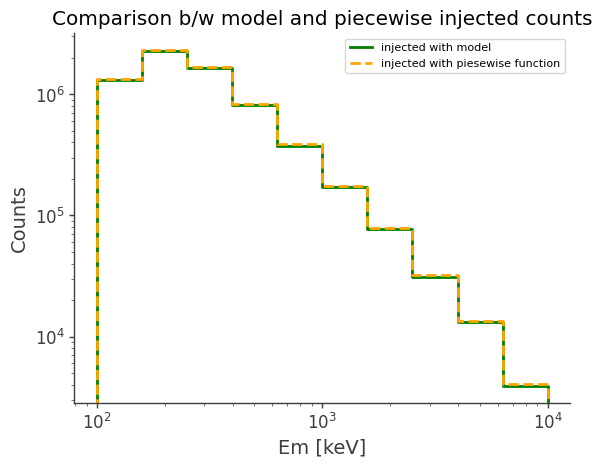

In [25]:
model_injected = Histogram.open("Crab_model_injected.h5").project("Em")
piecewise_injected = Histogram.open("Crab_piecewise_injected.h5").project("Em")

ax, plot = model_injected.draw(label="injected with model", color="green")

piecewise_injected.draw(
    ax, label="injected with piesewise function", color="orange", linestyle="dashed"
)


ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_ylabel("Counts")
ax.set_title("Comparison b/w model and piecewise injected counts")

Text(0.5, 1.0, 'Comparison b/w model and piecewise injected counts')

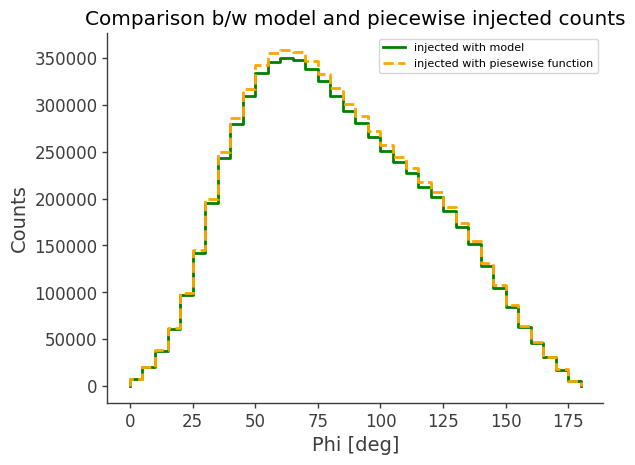

In [26]:
model_injected = Histogram.open("Crab_model_injected.h5").project("Phi")
piecewise_injected = Histogram.open("Crab_piecewise_injected.h5").project("Phi")

ax, plot = model_injected.draw(label="injected with model", color="green")

piecewise_injected.draw(
    ax, label="injected with piesewise function", color="orange", linestyle="dashed"
)

ax.legend()
ax.set_ylabel("Counts")
ax.set_title("Comparison b/w model and piecewise injected counts")

#### Plot PsiChi Sky Map

Total sky integral (counts × sr): 112424.89
Plotting PsiChi map in Galactic coordinates


(<matplotlib.image.AxesImage at 0x3361c1090>, <Mollview: >)

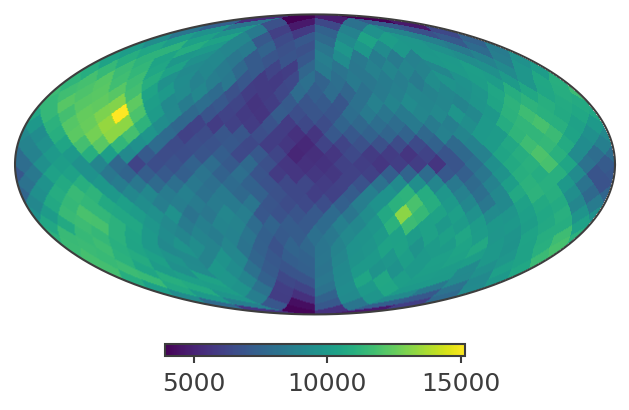

In [27]:
# Load PsiChi histogram (Compton data space sky map)
h_psichi = Histogram.open("Crab_piecewise_injected.h5").project("PsiChi")

# Healpix map from histogram contents (stored in Galactic coordinates)
skymap = HealpixMap(
    nside=h_psichi.axes["PsiChi"].nside,
    scheme="ring",
    dtype=float,
    coordsys="G",
)
skymap[:] = np.asarray(h_psichi.contents, dtype=float)

# Sky integral (counts × sr)
total = np.sum(skymap) * skymap.pixarea().value
print(f"Total sky integral (counts × sr): {total:.2f}")

# Plot in Galactic coordinates
print("Plotting PsiChi map in Galactic coordinates")
skymap.plot(ax_kw={"coord": "G"})

Plotting PsiChi map in ICRS coordinates


(<matplotlib.image.AxesImage at 0x334e16620>, <Mollview: >)

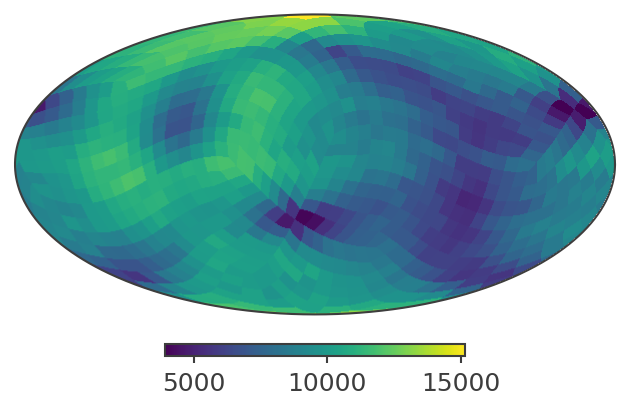

In [28]:
# Plot in ICRS / Equatorial coordinates
print("Plotting PsiChi map in ICRS coordinates")
skymap.plot(ax_kw={"coord": "C"})

## Inject Polarization


Get the latest polarization response


In [29]:
%%capture
response_path = data_dir/"ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5"

# download response file ~839.62 MB
fetch_wasabi_file("COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.pol.e200_10000.b4.p12.relx.s10396905069491.m420.filtered.binnedpolarization.11D.h5", response_path)

In [30]:
# Define an injector by the response
injector = SourceInjector(
    response_path=response_path,
    response_frame="spacecraftframe",
    pa_convention="RelativeX",  # or "RelativeY" / "RelativeZ"
)

In [31]:
# Define a linearly polarized source
# angle: polarization angle (deg), degree: polarization fraction (%)
pol = LinearPolarization(angle=45, degree=30)


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



CPU times: user 8.39 s, sys: 1.19 s, total: 9.58 s
Wall time: 7.37 s


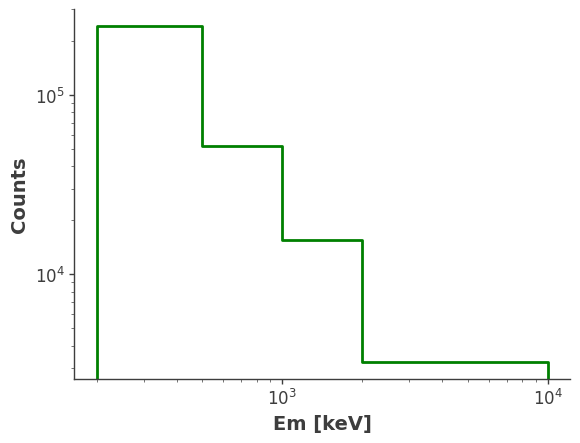

In [32]:
%%time

file_path = "Crab_piecewise_injected_pol.h5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source (now including polarization)
model_injected = injector.inject_model(
    model=model,
    orientation=ori,
    polarization=pol,
    make_spectrum_plot=True,
    data_save_path=file_path
)

Text(0.5, 1.0, 'Injected Crab')

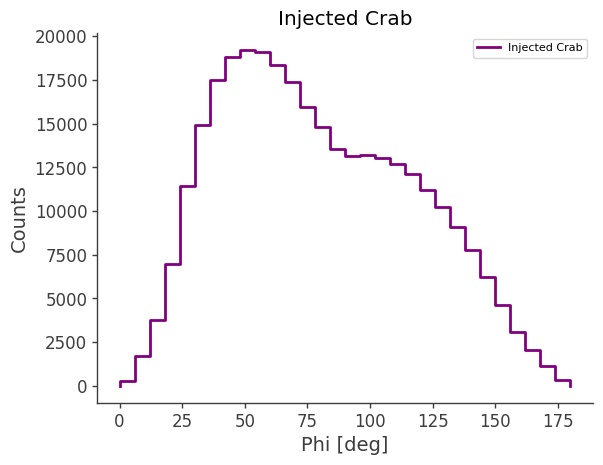

In [33]:
injected = Histogram.open("Crab_piecewise_injected_pol.h5")

ax, plot = injected.project("Phi").draw(label="Injected Crab", color="purple")

ax.legend()
ax.set_ylabel("Counts")
ax.set_title("Injected Crab")

#### Plot PsiChi Sky Map

Total sky integral (counts × sr): 5131.52
Plotting PsiChi map in Galactic coordinates


(<matplotlib.image.AxesImage at 0x3368cdd80>, <Mollview: >)

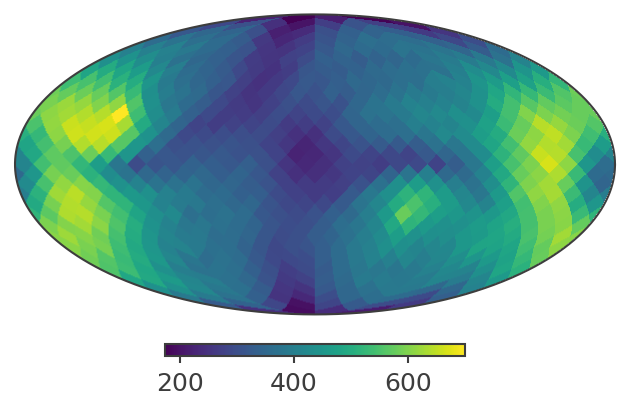

In [34]:
# Load PsiChi histogram (Compton data space sky map)
h_psichi = Histogram.open("Crab_piecewise_injected_pol.h5").project("PsiChi")

# Healpix map from histogram contents (stored in Galactic coordinates)
skymap = HealpixMap(
    nside=h_psichi.axes["PsiChi"].nside,
    scheme="ring",
    dtype=float,
    coordsys="G",
)
skymap[:] = np.asarray(h_psichi.contents, dtype=float)

# Sky integral (counts × sr)
total = np.sum(skymap) * skymap.pixarea().value
print(f"Total sky integral (counts × sr): {total:.2f}")

# Plot in Galactic coordinates
print("Plotting PsiChi map in Galactic coordinates")
skymap.plot(ax_kw={"coord": "G"})

Plotting PsiChi map in ICRS coordinates


(<matplotlib.image.AxesImage at 0x3363df490>, <Mollview: >)

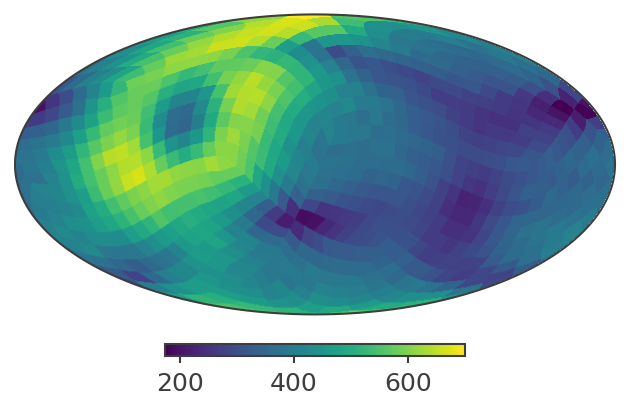

In [35]:
# Plot in ICRS / Equatorial coordinates
print("Plotting PsiChi map in ICRS coordinates")
skymap.plot(ax_kw={"coord": "C"})

#### Plot Azimuthal Scattering Angle Distribution (ASAD)


In [36]:
# Inputs
injected_path = "Crab_piecewise_injected_pol.h5"

# Crab (Galactic) -> ICRS (required by PolarizationAngle)
source_icrs = SkyCoord(
    l=184.5551, b=-5.7877, frame="galactic", unit="deg"
).transform_to("icrs")

convention = IAUPolarizationConvention()

# ASAD binning
nbins = 36
asad_edges = np.linspace(-np.pi, np.pi, nbins + 1)
asad_centers = 0.5 * (asad_edges[:-1] + asad_edges[1:])
asad_centers_deg = np.rad2deg(asad_centers)

# Load injected histogram
data = Histogram.open(injected_path)

# Scattering directions (PsiChi pixels) + weights (counts per pixel)
psichi_axis = data.axes["PsiChi"]
pix_idx = np.arange(psichi_axis.nbins)

scattering_dirs_icrs = psichi_axis.pix2skycoord(pix_idx).transform_to("icrs")
weights = np.asarray(data.project("PsiChi").contents, dtype=float)

print(f"PsiChi pixels: {psichi_axis.nbins}, total counts (PsiChi): {weights.sum():.2f}")

PsiChi pixels: 768, total counts (PsiChi): 313615.48


We build the azimuthal scattering angle distribution (ASAD), fit it with a sinusoid, and finally plot the result.

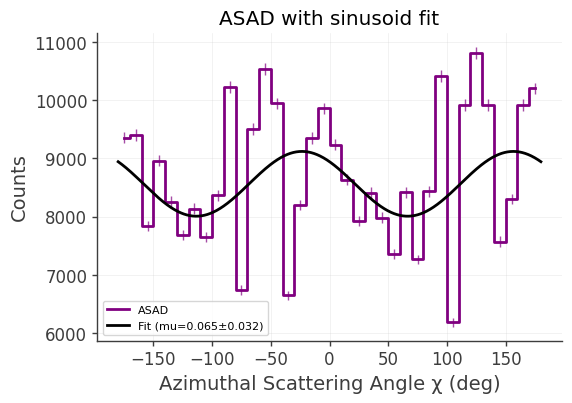

a=8.56e+03±195, b=556±274, c=66.51±14.32 deg
mu=0.0650±0.0320


In [37]:
def asad_sinusoid(x, a, b, c):
    return a - b * np.cos(2.0 * (x - c))


def fit_asad(
    x, y, sigma=None, p0=None, bounds=((0.0, 0.0, -np.pi), (np.inf, np.inf, np.pi))
):
    popt, pcov = curve_fit(asad_sinusoid, x, y, p0=p0, bounds=bounds, sigma=sigma)
    return popt, np.sqrt(np.diag(pcov))


def calculate_mu(params, perr):
    a, b, _ = params
    da, db, _ = perr
    mu = b / a
    mu_err = np.sqrt((db / a) ** 2 + ((b * da) / (a**2)) ** 2)
    return mu, mu_err


# azimuthal scattering angles
az = PolarizationAngle.from_scattering_direction(
    scattering_dirs_icrs, source_icrs, convention
)
chi = az.angle
chi_rad = np.asarray(
    chi.to_value(u.rad) if hasattr(chi, "to_value") else chi, dtype=float
)

# ASAD
asad_counts, _ = np.histogram(chi_rad, bins=asad_edges, weights=weights)
asad_unc = np.sqrt(np.maximum(asad_counts, 1.0))

centers = 0.5 * (asad_edges[1:] + asad_edges[:-1])  # rad
centers_deg = np.rad2deg(centers)

# fit
p0 = [
    float(np.mean(asad_counts)),
    float(0.5 * (np.max(asad_counts) - np.min(asad_counts))),
    0.0,
]

params, perr = fit_asad(centers, asad_counts, sigma=asad_unc, p0=p0)
mu, mu_err = calculate_mu(params, perr)

xfit = np.linspace(-np.pi, np.pi, 1000)
yfit = asad_sinusoid(xfit, *params)

# plot
plt.figure(figsize=(6, 4))
plt.step(centers_deg, asad_counts, where="mid", color="purple", label="ASAD")
plt.errorbar(
    centers_deg,
    asad_counts,
    yerr=asad_unc,
    fmt="none",
    ecolor="purple",
    elinewidth=1,
    alpha=0.7,
)
plt.plot(
    np.rad2deg(xfit), yfit, color="black", lw=2, label=f"Fit (mu={mu:.3f}±{mu_err:.3f})"
)
plt.xlabel("Azimuthal Scattering Angle χ (deg)")
plt.ylabel("Counts")
plt.title("ASAD with sinusoid fit")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

a, b, c = params
da, db, dc = perr
print(
    f"a={a:.3g}±{da:.3g}, b={b:.3g}±{db:.3g}, c={np.rad2deg(c):.2f}±{np.rad2deg(dc):.2f} deg"
)
print(f"mu={mu:.4f}±{mu_err:.4f}")

The sinusoidal modulation of the azimuthal scattering angle is a signature of polarization in the source.